<a href="https://colab.research.google.com/github/Zkyusya/dirty_cafe_sales_data_analyis/blob/main/dirty_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('dirty_cafe_sales.csv')

In [2]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


**# Data Describe**

From the above data:-
1. **Count** - Number of non-null entries in each column. For example, Transaction ID has 10,000 entries, but Payment Method only has 7,421, meaning some are missing.
2. **Unique** - Number of distinct values. For instance, there are 10 different items sold, 5 payment methods,4 locations and 367 distinct transaction dates.
3. **Top** - The most frequent value in that column. For example, the most common item is Juice, the most common payment method is Digital Wallet, and the most common location is Takeaway.
4. **Freq** - How many times the “top” value appears. Juice appears 1,171 times, Digital Wallet 2,291 times, and Takeaway 3,022 times.


**This informs us that;**

**Transaction IDs** are all unique (10,000 unique values, each with frequency 1).

**Items:** Juice is the most popular product, sold 1,171 times.

**Quantities:** The most common purchase quantity is 5 units, appearing 2,013 times.

**Prices**:The most frequent price per unit is 3.0, showing up 2,429 times.

**Spending:** The most common total spent is 6.0, with 979 occurrences.

**Payment methods:** Digital Wallet dominates with 2,291 transactions.

**Locations:** Takeaway is the most frequent location, with 3,022 transactions.

**Dates:** There are 367 distinct transaction dates, but 159 entries are marked as “UNKNOWN.”




After studying the data above, we will not drop any row with missing values since they are not >50 which means they still hold valuable information that will assist in decision making.

**Data Cleaning**

Lets get our hands dirty by cleaning the data.

**Handling Missing Values**
*   No rows will be dropped
*   We will be applying Statistical Imputation

Numeric Columns(Quantity, price per unit, total spent) which are often skewed, we will use median.
For Categorical colums(Item, Payment Method, Location) we will use mode imputation.
For transaction date, we will infer dates from transaction ID ordering since IDs often encode time.





In [6]:
#median imputation for skewed numeric columns
numeric_columns = ['Quantity', 'Price per Unit', 'Total Spent']
for col in numeric_columns:
    median = df[col].median()
    df[col].fillna(df[col].median(), inplace=True)

#mode imputation for categorical
categorical_columns = ['Item', 'Payment Method', 'Location']
for col in categorical_columns:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

TypeError: Cannot convert ['2' '4' '4' ... '4' '3' '3'] to numeric

There was an error while using median to replace the numeric values.This is because the quantity, price per unit and total spent colums is stored as text(object) instead of numbers.We will now convert these columns to a numeric type, coercing any non-numeric entries into NaN.

In [7]:
#median imputation for skewed numeric columns
numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_columns:
    #convert column to numeric, coercing errors to Nan
    df[col] = pd.to_numeric(df[col], errors='coerce')
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

#mode imputation for categorical
categorical_columns = ['Item', 'Payment Method', 'Location']
for col in categorical_columns:
    mode = df[col].mode()[0]
    df[col].fillna(mode, inplace=True)

#forward-fill missing dates from previous transaction
df['Transaction Date'].replace('Unknown', pd.NA, inplace=True)
df['Transaction Date'] .fillna(method='ffill', inplace=True)

#backforward-fill remaining gaps if any
df['Transaction Date'].fillna(method='bfill', inplace=True)


/tmp/ipykernel_696/2785230083.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
/tmp/ipykernel_696/2785230083.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              10000 non-null  object 
 2   Quantity          10000 non-null  float64
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       10000 non-null  float64
 5   Payment Method    10000 non-null  object 
 6   Location          10000 non-null  object 
 7   Transaction Date  10000 non-null  object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [9]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,10000,10000.000000,10000.00000,10000.00000,10000,10000,10000
unique,10000,10,NaN,NaN,NaN,5,4,367
top,TXN_9226047,Juice,NaN,NaN,NaN,Digital Wallet,Takeaway,UNKNOWN
freq,1,1504,NaN,NaN,NaN,4870,6287,160
mean,NaN,NaN,3.027100,2.95265,8.87795,NaN,NaN,NaN
std,NaN,NaN,1.384614,1.24396,5.86059,NaN,NaN,NaN
min,NaN,NaN,1.000000,1.00000,1.00000,NaN,NaN,NaN
25%,NaN,NaN,2.000000,2.00000,4.00000,NaN,NaN,NaN
50%,NaN,NaN,3.000000,3.00000,8.00000,NaN,NaN,NaN
75%,NaN,NaN,4.000000,4.00000,12.00000,NaN,NaN,NaN


In [10]:
df.isna().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [11]:
# Find exact duplicates
exact_dupes = df[df.duplicated(keep=False)]
print("Exact duplicate rows:\n", exact_dupes)

# Find duplicate Transaction IDs
txn_dupes = df[df.duplicated(subset=["Transaction ID"], keep=False)]
print("Rows with duplicate Transaction IDs:\n", txn_dupes)


Exact duplicate rows:
 Empty DataFrame
Columns: [Transaction ID, Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date]
Index: []
Rows with duplicate Transaction IDs:
 Empty DataFrame
Columns: [Transaction ID, Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date]
Index: []


In [12]:
# Group by Transaction ID to see variations
dupe_analysis = df.groupby("Transaction ID").agg({
    "Item": pd.Series.nunique,
    "Transaction Date": pd.Series.nunique
}).reset_index()

print("Duplicate analysis:\n", dupe_analysis[dupe_analysis["Item"] > 1])


Duplicate analysis:
 Empty DataFrame
Columns: [Transaction ID, Item, Transaction Date]
Index: []


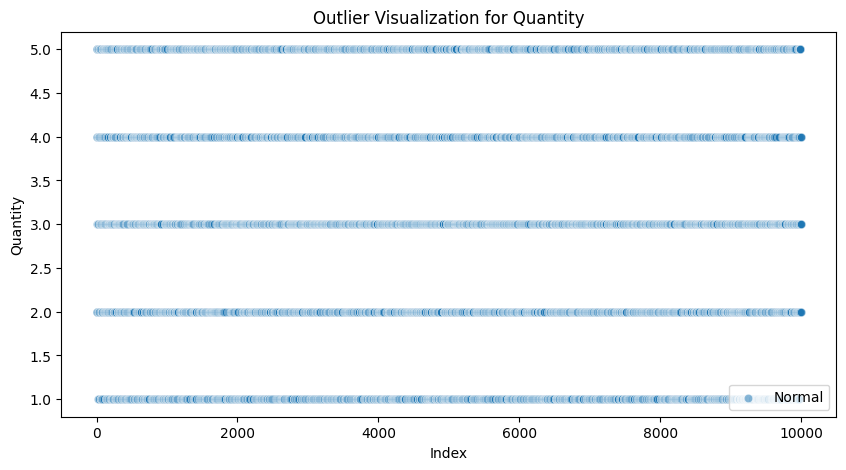

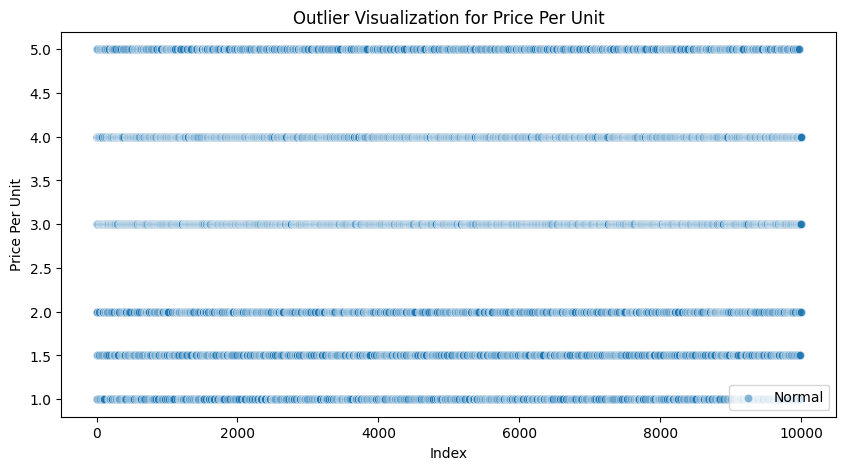

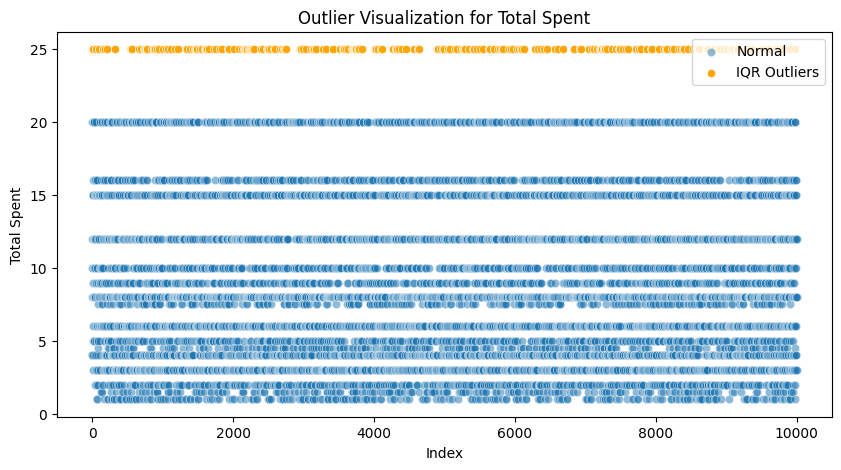

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# Numeric columns
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

# --- Functions to flag outliers ---
def zscore_flags(series, threshold=3):
    # Convert to numeric, coercing errors. This series might contain NaNs.
    numeric_s = pd.to_numeric(series, errors="coerce")

    # Calculate z-scores only for non-NaN values
    non_nan_s = numeric_s.dropna()
    if non_nan_s.empty:
        return pd.Series(False, index=series.index) # Return all False if no valid numbers

    z_scores = stats.zscore(non_nan_s)

    # Create a boolean series with the original index, initially all False
    flags = pd.Series(False, index=series.index)

    # Apply the outlier condition to the non-NaN part and map back to the original index
    flags.loc[non_nan_s.index] = np.abs(z_scores) > threshold
    return flags

def iqr_flags(series):
    # Convert to numeric, coercing errors. This series might contain NaNs.
    numeric_s = pd.to_numeric(series, errors="coerce")

    # Calculate IQR bounds only for non-NaN values
    non_nan_s = numeric_s.dropna()
    if non_nan_s.empty:
        return pd.Series(False, index=series.index) # Return all False if no valid numbers

    Q1 = non_nan_s.quantile(0.25)
    Q3 = non_nan_s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a boolean series with the original index, initially all False
    flags = pd.Series(False, index=series.index)

    # Apply the outlier condition to the non-NaN part and map back to the original index
    flags.loc[non_nan_s.index] = (non_nan_s < lower_bound) | (non_nan_s > upper_bound)
    return flags

# --- Visualization with highlighted outliers ---
for col in numeric_cols:
    plt.figure(figsize=(10, 5))

    # Convert column to numeric, coercing errors. This series is what we're plotting.
    series_for_plot = pd.to_numeric(df[col], errors="coerce")

    # Flag outliers using the new functions
    z_flags = zscore_flags(series_for_plot)
    iqr_flags_ = iqr_flags(series_for_plot)

    # The 'Normal' points are those that are NOT flagged by either method and are NOT NaN
    normal_mask = ~(z_flags | iqr_flags_) & ~series_for_plot.isna()

    # Scatter plot with coloring
    sns.scatterplot(x=series_for_plot.index[normal_mask], y=series_for_plot[normal_mask],
                    alpha=0.5, label="Normal")

    sns.scatterplot(x=series_for_plot.index[z_flags], y=series_for_plot[z_flags],
                    color="red", label="Z-score Outliers")

    sns.scatterplot(x=series_for_plot.index[iqr_flags_], y=series_for_plot[iqr_flags_],
                    color="orange", label="IQR Outliers")

    plt.title(f"Outlier Visualization for {col}")
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.legend()
    plt.show()

In [14]:
import pandas as pd
import numpy as np
from scipy import stats

numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

def zscore_flags(series, threshold=3):
    series = pd.to_numeric(series, errors="coerce").dropna()
    z_scores = stats.zscore(series)
    return np.abs(z_scores) > threshold

def iqr_flags(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# --- Summary table ---
summary = []
for col in numeric_cols:
    series = pd.to_numeric(df[col], errors="coerce")
    z_flags = zscore_flags(series)
    iqr_flags_ = iqr_flags(series)

    summary.append({
        "Column": col,
        "Total Rows": series.count(),
        "Z-score Outliers": z_flags.sum(),
        "IQR Outliers": iqr_flags_.sum()
    })

outlier_summary = pd.DataFrame(summary)
print(outlier_summary)

           Column  Total Rows  Z-score Outliers  IQR Outliers
0        Quantity       10000                 0             0
1  Price Per Unit       10000                 0             0
2     Total Spent       10000                 0           259


The 259 outliers flagged mean that those transactions were outside the normal range of (Q1-1.5*IQR and Q3+1.5*IQR). The scatter plot shows ornage points concentrated at the top, meaning these are extremely high spending transactions.
They could mean genuine customers buying unusually large quantity items or expensive items, data entry errors, special promotions.

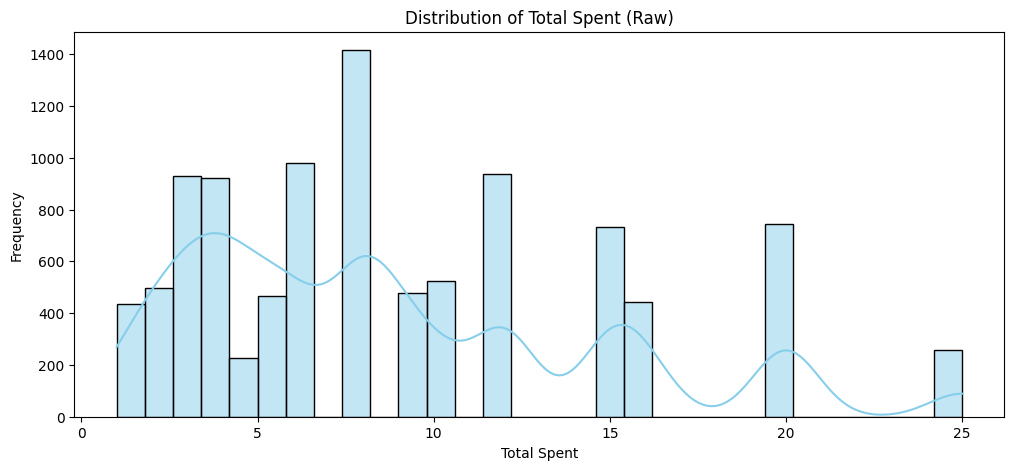

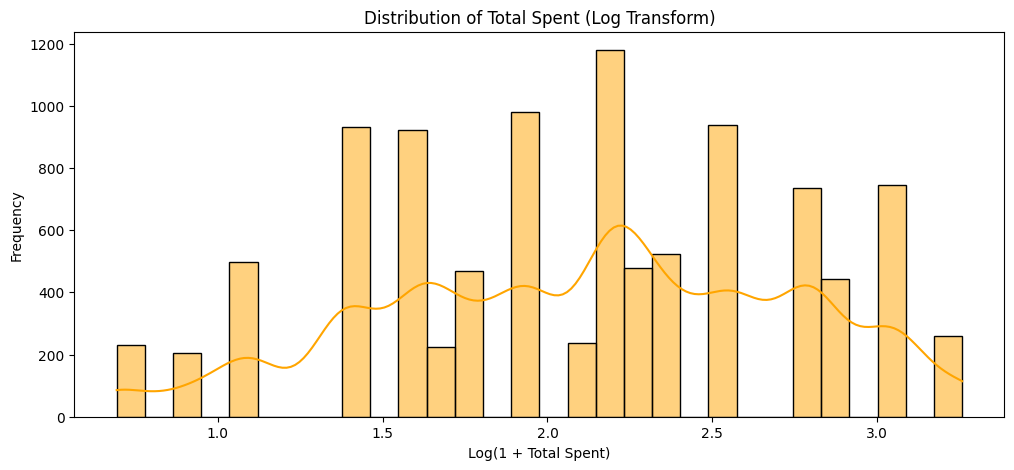

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Convert to numeric safely
total_spent = pd.to_numeric(df["Total Spent"], errors="coerce")

# --- Histogram of raw values ---
plt.figure(figsize=(12,5))
sns.histplot(total_spent, bins=30, kde=True, color="skyblue")
plt.title("Distribution of Total Spent (Raw)")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

# --- Histogram of log-transformed values ---
plt.figure(figsize=(12,5))
sns.histplot(np.log1p(total_spent), bins=30, kde=True, color="orange")
plt.title("Distribution of Total Spent (Log Transform)")
plt.xlabel("Log(1 + Total Spent)")
plt.ylabel("Frequency")
plt.show()


From this distribution, we learn that most transactions cluster at lower total spent values, with a stretch up to cap at 25. From the log-transformed histogram, the skewness is reduced and the distribution looks smoother.

Since the data has no duplicates to be dropped, We can now move to  Exploratory Data Analysis (EDA) to uncover data structure, relationships, and potential predictive features.

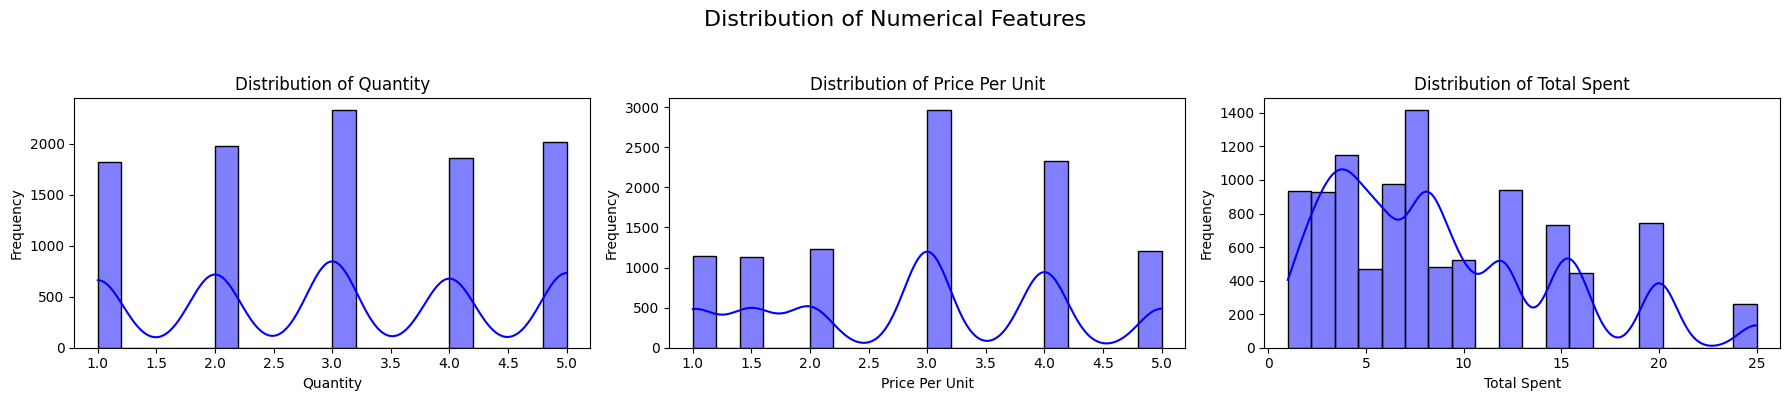

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

# Create subplots for the histograms
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(18, 4))

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color="blue", edgecolor="black")
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle("Distribution of Numerical Features", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


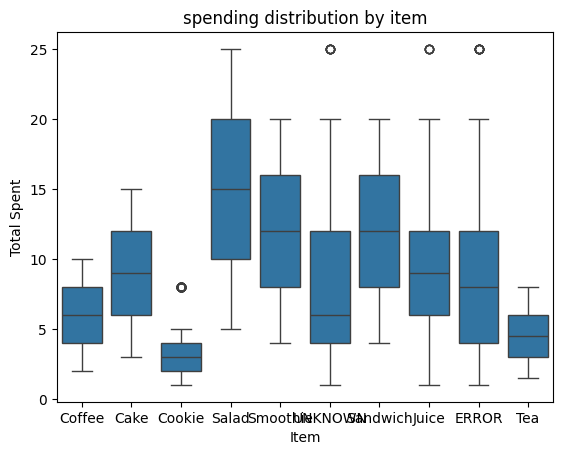

In [17]:
sns.boxplot(x="Item", y="Total Spent", data=df)
plt.title("spending distribution by item")
plt.show()

To continue with EDA, Lets have bar chart for univariate analysis to see the most purchased items, payment preferences and transaction locations.

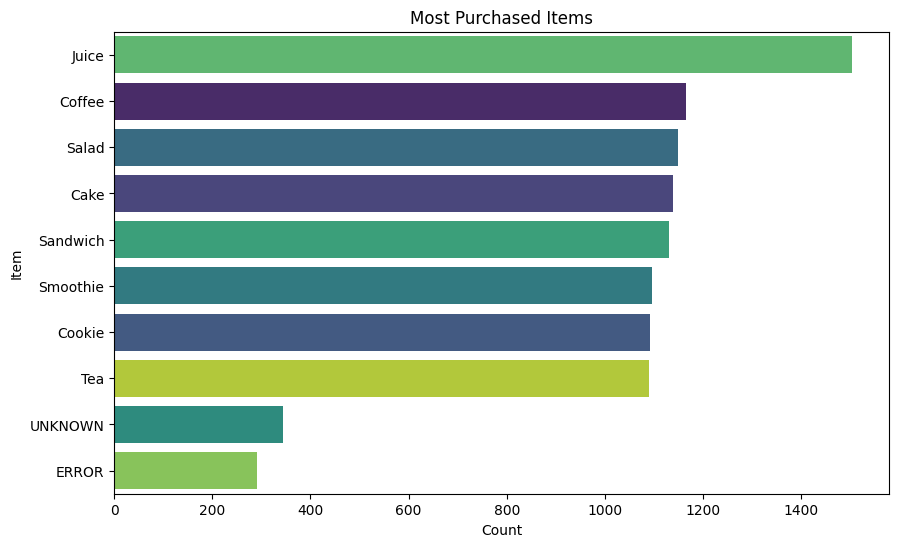

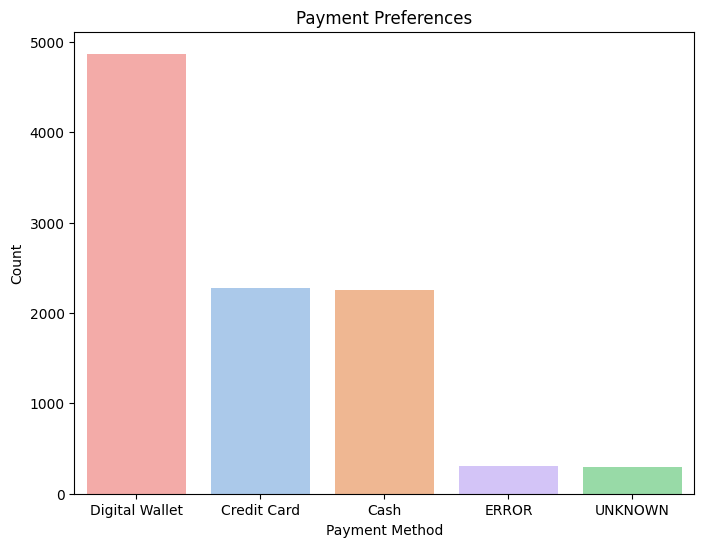

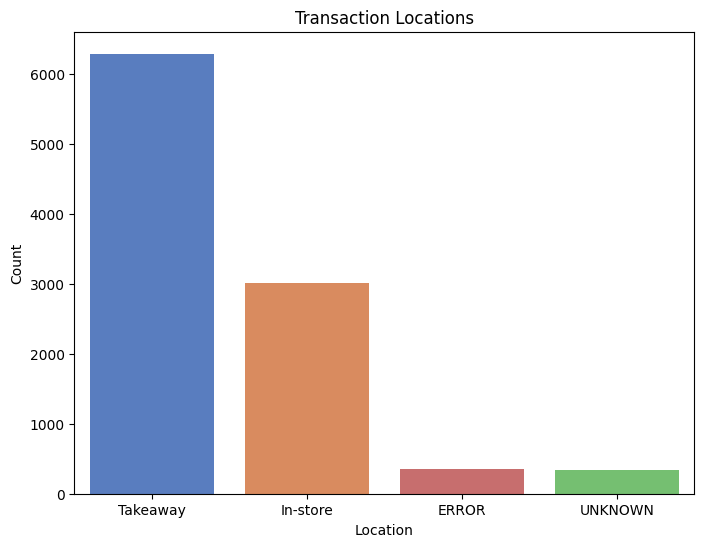

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Most purchased items ---
plt.figure(figsize=(10,6))
sns.countplot(y="Item", data=df,
              order=df["Item"].value_counts().index,
              hue="Item", palette="viridis", legend=False)
plt.title("Most Purchased Items")
plt.xlabel("Count")
plt.ylabel("Item")
plt.show()

# --- Payment preferences ---
plt.figure(figsize=(8,6))
sns.countplot(x="Payment Method", data=df,
              order=df["Payment Method"].value_counts().index,
              hue="Payment Method", palette="pastel", legend=False)
plt.title("Payment Preferences")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

# --- Transaction locations ---
plt.figure(figsize=(8,6))
sns.countplot(x="Location", data=df,
              order=df["Location"].value_counts().index,
              hue="Location", palette="muted", legend=False)
plt.title("Transaction Locations")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

Now, lets have a time series plot to detect seasonality , showing both daily transactions and monthly transaction

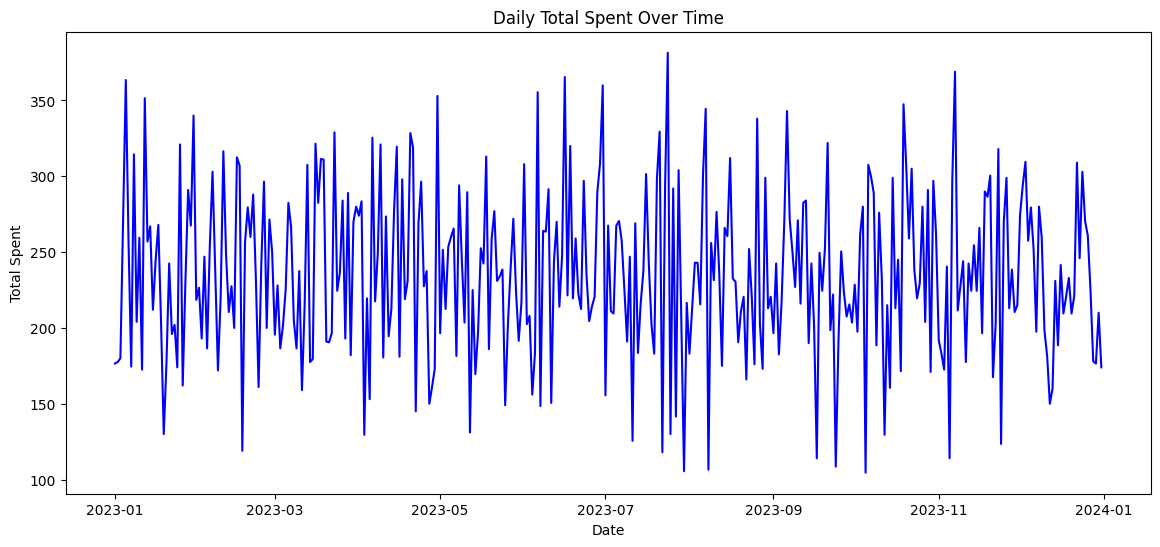

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Transaction Date is in datetime format
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Drop rows where date conversion failed
df = df.dropna(subset=["Transaction Date"])

# Group by date and sum Total Spent
daily_sales = df.groupby(df["Transaction Date"].dt.date)["Total Spent"].sum()

# Convert index back to datetime for plotting
daily_sales.index = pd.to_datetime(daily_sales.index)

# Plot time series
plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values, color="blue")
plt.title("Daily Total Spent Over Time")
plt.xlabel("Date")
plt.ylabel("Total Spent")
plt.show()

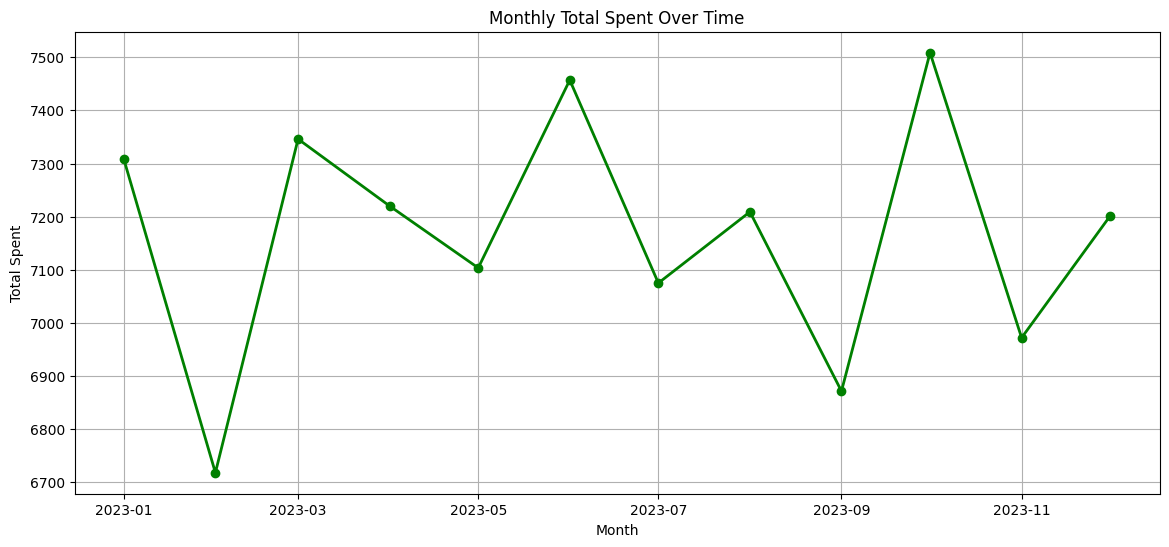

In [20]:
# Monthly aggregation
monthly_sales = df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="green", linewidth=2)
plt.title("Monthly Total Spent Over Time")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.grid(True)
plt.show()


Having understood our data, lets do a bivariate analysis;
1. Item vs total spent - which items generated the highest revenue
2. payment method vs total spent - do digital wallets correlate with higher spending?
3. Location vs quantity - are takeaway orde larger than in store?
4. Time vs sales - seasonal or daily patterns in spending

/tmp/ipykernel_696/2264452166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_revenue.values, y=item_revenue.index, palette="viridis")


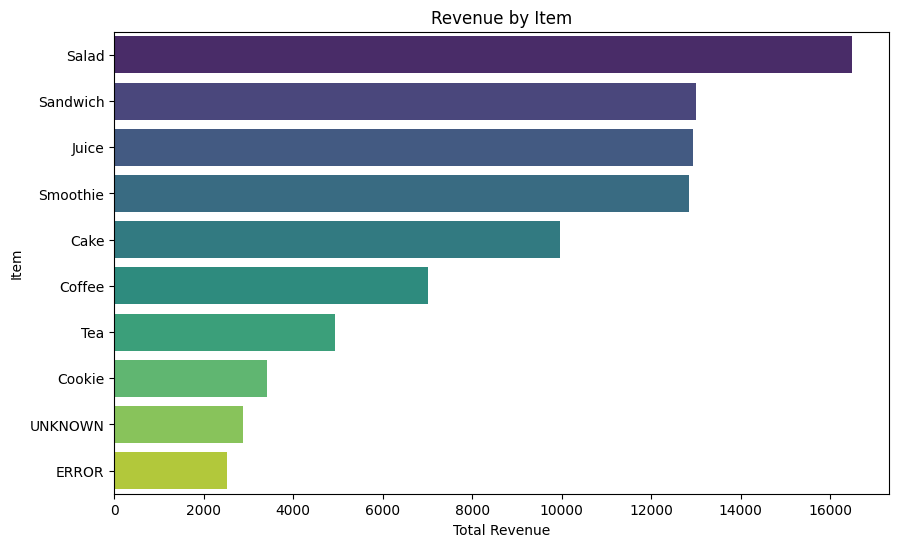

In [21]:
# Revenue per item
item_revenue = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=item_revenue.values, y=item_revenue.index, palette="viridis")
plt.title("Revenue by Item")
plt.xlabel("Total Revenue")
plt.ylabel("Item")
plt.show()


/tmp/ipykernel_696/2198590109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_revenue.index, y=payment_revenue.values, palette="pastel")


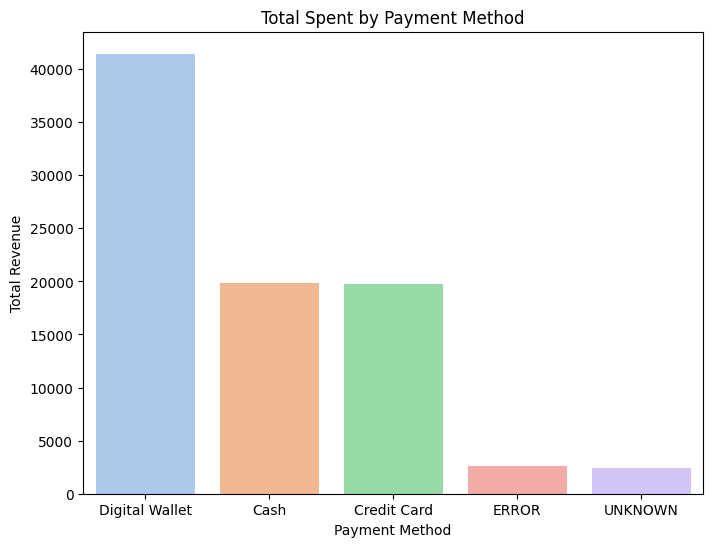

In [22]:
# Total spent by payment method
payment_revenue = df.groupby("Payment Method")["Total Spent"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=payment_revenue.index, y=payment_revenue.values, palette="pastel")
plt.title("Total Spent by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.show()


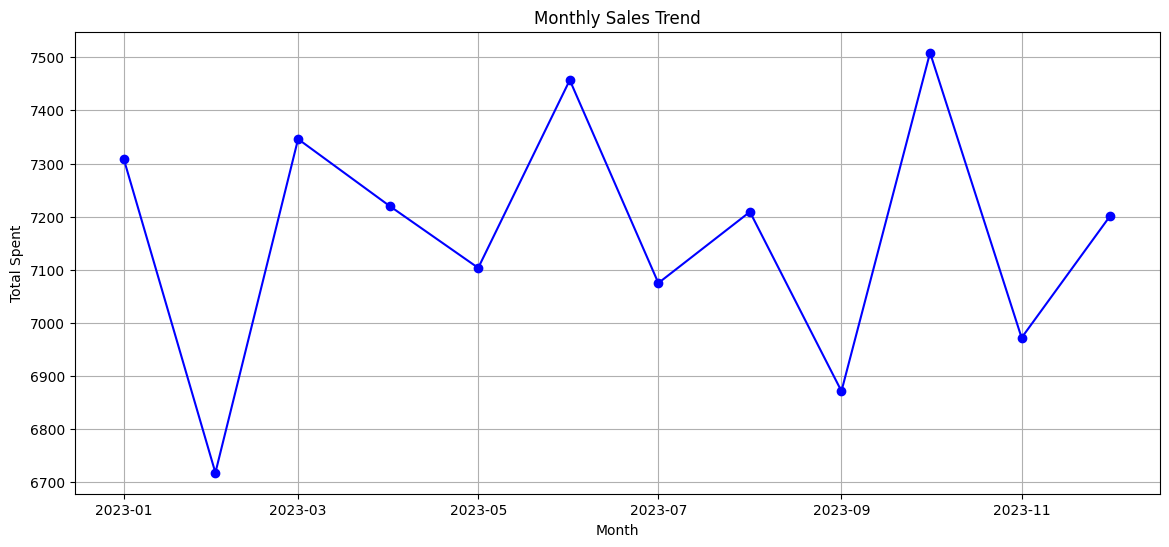

In [23]:
# Convert Transaction Date
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
# Group by month
monthly_sales = df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="blue")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.grid(True)
plt.show()


Lets do a correlation analysis to check numerical relationships to help us in our next step of feature engineering. Is the total spent influenced by quantity and price per unit?

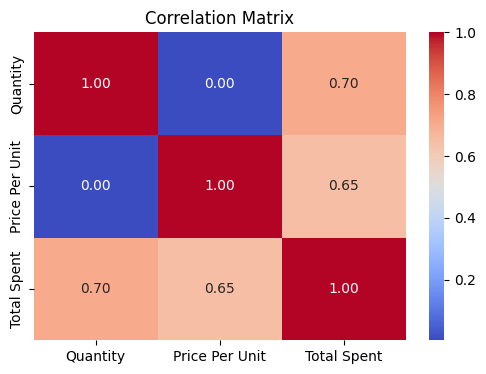

In [ ]:
# Correlation matrix for numeric features
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

corr = df[["Quantity", "Price Per Unit", "Total Spent"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

We can conclude that as the number of items purchased incrases, the total spending also increase(0.70). The price per unit and total spent correlation is slightly weaker. The number of items purchased doesnt depend on the price per unit since customers buy varying quantities regardless of whether items are cheap or expensive. Each factor influences spending behaviour but separately.

**Hypothesis Testing**

Using the above analysis, lets formulate hypothesis to validate them.

1. Item popularity drives revenue e.g juice.
2. Payment Method may predict Total Spent.
3. Location affects purchase size.
4. Seasonality affects spending.

The data contains error and nan values that brings an error during the hypothesis testing, which needs to be dropped to ensure we remain with numerical values only.

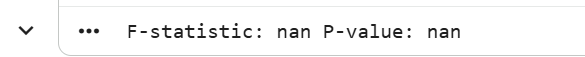



In [24]:
# Drop all rows with any NaN values
df_clean = df.dropna()

# Check shape before and after
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Original shape: (9696, 8)
Cleaned shape: (9696, 8)


**Hypothesis 1: Item Popularity vs Revenue**

H0: Revenue is evenly distributed across items; item popularity directly drives revenue.

H1: Revenue differs significantly across items; popularity ≠ revenue contribution.

In [25]:
from scipy.stats import f_oneway

# Ensure numeric conversion using .loc to avoid SettingWithCopyWarning
df_clean.loc[:, 'Total Spent'] = pd.to_numeric(df_clean['Total Spent'], errors='coerce')

# Drop rows with NaN in 'Total Spent' after coercion, as f_oneway cannot handle NaNs
df_clean_numeric_spent = df_clean.dropna(subset=['Total Spent'])

# Group revenue by item
item_groups = []
for name, group in df_clean_numeric_spent.groupby("Item"):
    values = group["Total Spent"].values
    # Only include groups with at least 2 observations
    if len(values) > 1:
        item_groups.append(values)

# Run ANOVA if we have at least 2 valid groups
if len(item_groups) > 1:
    f_stat, p_val = f_oneway(*item_groups)
    print("Item vs Revenue = F-statistic:", f_stat, "P-value:", p_val)
else:
    print("Not enough valid groups for ANOVA")

Item vs Revenue = F-statistic: 606.5129598464558 P-value: 0.0


**Hypothesis 2: Payment Method vs Spending**

H0: Average spending is the same across payment methods.

H1: Average spending differs by payment method (e.g. digital wallets lead to higher spending).

In [26]:
# Ensure numeric conversion
df_clean.loc[:, 'Total Spent'] = pd.to_numeric(df_clean['Total Spent'], errors='coerce')
df_clean_numeric_spent = df_clean.dropna(subset=['Total Spent'])

# Group spending by payment method
payment_groups = []
for name, group in df_clean_numeric_spent.groupby("Payment Method"):
    values = group["Total Spent"].values
    if len(values) > 1:  # Only include groups with at least 2 observations
        payment_groups.append(values)

# Run ANOVA if valid groups exist
if len(payment_groups) > 1:
    f_stat, p_val = f_oneway(*payment_groups)
    print("Payment Method vs Spending = F-statistic:", f_stat, "P-value:", p_val)
else:
    print("Not enough valid groups for ANOVA")

Payment Method vs Spending = F-statistic: 1.5199172290225604 P-value: 0.19337006438994186


**Hypothesis 3: Location vs Purchase Size**

H0: Average quantity purchased is the same across locations (Takeaway vs In-store).

H1: Average quantity differs by location (e.g., takeaway orders are larger).

In [30]:
from scipy.stats import ttest_ind

# Ensure numeric conversion
df_clean.loc[:, 'Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean_quantity = df_clean.dropna(subset=['Quantity'])

# Split quantities by location and explicitly cast to float
takeaway_qty = df_clean_quantity[df_clean_quantity["Location"]=="Takeaway"]["Quantity"].astype(float)
instore_qty = df_clean_quantity[df_clean_quantity["Location"]=="In-store"]["Quantity"].astype(float)

# Run t-test if both groups have at least 2 observations
if len(takeaway_qty) > 1 and len(instore_qty) > 1:
    t_stat, p_val = ttest_ind(takeaway_qty, instore_qty, equal_var=False)
    print("Location vs Quantity = T-statistic:", t_stat, "P-value:", p_val)
else:
    print("Not enough valid data for t-test")

Location vs Quantity = T-statistic: 0.2911660388856949 P-value: 0.7709348589938647


**Hypothesis 4: Seasonality vs Spending**

H0: Spending is uniform across time; no seasonal variation.

H1: Spending varies significantly by month/season.

In [28]:
# Ensure datetime conversion by first converting to string, then to datetime
df_clean["Transaction Date"] = pd.to_datetime(df_clean["Transaction Date"],errors="coerce")

df_clean = df_clean.dropna(subset=["Transaction Date", "Total Spent"])

# Extract month
df_clean["Month"] = df_clean["Transaction Date"].dt.month

# Group spending by month
monthly_groups = []
for name, group in df_clean.groupby("Month"):
    values = group["Total Spent"].values
    if len(values) > 1:  # Only include months with at least 2 observations
        monthly_groups.append(values)

# Run ANOVA if valid groups exist
if len(monthly_groups) > 1:
    f_stat, p_val = f_oneway(*monthly_groups)
    print("Seasonality vs Spending = F-statistic:", f_stat, "P-value:", p_val)
else:
    print("Not enough valid groups for ANOVA")

Seasonality vs Spending = F-statistic: 0.5263043745732774 P-value: 0.8869826349331749


From the above hypotheses, we can conclude that item popularity does not guarantee revenue generation. Revenue depends on the quantity and price. In addition, factors like payment method, loacation and season do not significantly influence spending.

Lets move to **Feature Engineering**

**Features we will include:**

1. Date features- We will Extract day, month, year, weekday, hour from Transaction Date.

2. Spending features- Average spend per item (Total Spent / Quantity).

3. Categorical encoding - Convert Item, Payment Method, Location into numeric codes or one-hot vectors.

**What we will not inclue:**

1. Transaction ID - not predictive.
2. Redundant features e.g. Total Spent since its already derived from Quantity*Price Per Unit.


In [27]:
# Date features
df_clean["Transaction Date"] = pd.to_datetime(df_clean["Transaction Date"], errors="coerce")
df_clean["Day"] = df_clean["Transaction Date"].dt.day
df_clean["Month"] = df_clean["Transaction Date"].dt.month
df_clean["Year"] = df_clean["Transaction Date"].dt.year
df_clean["Weekday"] = df_clean["Transaction Date"].dt.weekday

# Spending features
df_clean["Avg Spend Per Item"] = df_clean["Total Spent"] / df_clean["Quantity"]

# Categorical encoding
df_encoded = pd.get_dummies(df_clean, columns=["Item","Payment Method","Location"], drop_first=True)


**Interaction Features**

These capture relationships between variables.

**What to include**

Quantity * Price Per Unit - already equals Total Spent, but its useful for validation.

Payment Method * Location -for example digital wallet usage in takeaway vs in-store.

Item * Season - item popularity across months.

**What not to include**

Features that are perfectly collinear e.g., Total Spent and Quantity * Price Per Unit together.

In [31]:
# Interaction features
df_encoded["Qty_Price_Interaction"] = pd.to_numeric(df_clean["Quantity"], errors="coerce") * pd.to_numeric(df_clean["Price Per Unit"], errors="coerce")
df_encoded["Wallet_Takeaway"] = ((df_clean["Payment Method"]=="Digital Wallet") &
                                 (df_clean["Location"]=="Takeaway")).astype(int)
df_encoded["Item_Month"] = df_clean["Item"].astype(str) + "_" + df_clean["Month"].astype(str)

Feature Selection - We now drop useless columns using statistical tests

In [32]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Create a copy to avoid modifying the original dataframe
df_for_variance_selection = df_encoded.copy()

# Drop columns that should not be used for variance selection
columns_to_drop = [
    "Transaction Date",
    "Item_Month",
    "Transaction ID"
]

df_for_variance_selection = df_for_variance_selection.drop(
    columns=columns_to_drop,
    errors="ignore"
)

# Columns that should be numeric
numeric_cols = [
    "Quantity",
    "Price Per Unit",
    "Avg Spend Per Item"
]

# Convert to numeric and replace invalid values (e.g., 'UNKNOWN') with NaN
for col in numeric_cols:
    if col in df_for_variance_selection.columns:
        df_for_variance_selection[col] = pd.to_numeric(
            df_for_variance_selection[col],
            errors="coerce"
        )

# Fill missing numeric values with the median
for col in numeric_cols:
    if col in df_for_variance_selection.columns:
        df_for_variance_selection[col] = df_for_variance_selection[col].fillna(
            df_for_variance_selection[col].median()
        )

# Check for any remaining non-numeric columns
remaining_non_numeric = df_for_variance_selection.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Remaining non-numeric columns:", remaining_non_numeric)

# If there are still categorical columns, encode them
if len(remaining_non_numeric) > 0:
    df_for_variance_selection = pd.get_dummies(
        df_for_variance_selection,
        columns=remaining_non_numeric,
        drop_first=True
    )

# Apply Variance Threshold
selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(df_for_variance_selection)

# Get names of selected features
selected_features = df_for_variance_selection.columns[
    selector.get_support()
]

print("\nSelected Features:")
print(selected_features.tolist())

print("\nOriginal Shape:", df_for_variance_selection.shape)
print("Reduced Shape:", X_selected.shape)

Remaining non-numeric columns: ['Item_Coffee', 'Item_Cookie', 'Item_ERROR', 'Item_Juice', 'Item_Salad', 'Item_Sandwich', 'Item_Smoothie', 'Item_Tea', 'Item_UNKNOWN', 'Payment Method_Credit Card', 'Payment Method_Digital Wallet', 'Payment Method_ERROR', 'Payment Method_UNKNOWN', 'Location_In-store', 'Location_Takeaway', 'Location_UNKNOWN']

Selected Features:
['Quantity', 'Price Per Unit', 'Total Spent', 'Day', 'Month', 'Weekday', 'Avg Spend Per Item', 'Qty_Price_Interaction', 'Wallet_Takeaway', 'Item_Coffee_True', 'Item_Cookie_True', 'Item_ERROR_True', 'Item_Juice_True', 'Item_Salad_True', 'Item_Sandwich_True', 'Item_Smoothie_True', 'Item_Tea_True', 'Item_UNKNOWN_True', 'Payment Method_Credit Card_True', 'Payment Method_Digital Wallet_True', 'Payment Method_ERROR_True', 'Payment Method_UNKNOWN_True', 'Location_In-store_True', 'Location_Takeaway_True', 'Location_UNKNOWN_True']

Original Shape: (9696, 26)
Reduced Shape: (9696, 25)


**Dimensionality Reduction (PCA)**

Principal Component Analysis compresses features into fewer dimensions while retaining variance.
We include numerical features and Exclude categorical IDs.

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data
# Create a copy
df_pca = df_encoded.copy()

# Drop non-feature columns
df_pca = df_pca.drop(
    columns=["Transaction Date", "Item_Month", "Transaction ID"],
    errors="ignore"
)

# Convert known numeric columns
numeric_cols = ["Quantity", "Price Per Unit", "Avg Spend Per Item"]

for col in numeric_cols:
    if col in df_pca.columns:
        df_pca[col] = pd.to_numeric(df_pca[col], errors="coerce")

# Fill missing values
for col in df_pca.columns:
    if df_pca[col].dtype in ["int64", "float64"]:
        df_pca[col] = df_pca[col].fillna(df_pca[col].median())

# Encode any remaining categorical variables
non_numeric_cols = df_pca.select_dtypes(exclude=["number"]).columns

if len(non_numeric_cols) > 0:
    df_pca = pd.get_dummies(
        df_pca,
        columns=non_numeric_cols,
        drop_first=True
    )

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# PCA
# Keep enough components to explain 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca_result = pd.DataFrame(X_pca, columns=pca_columns)

# Results
print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(sum(pca.explained_variance_ratio_))

print("\nPCA Data:")
print(df_pca_result.head())

Original Shape: (9696, 26)
Reduced Shape: (9696, 17)

Explained Variance Ratio:
[0.16277587 0.0983079  0.06814998 0.06641543 0.04685225 0.04564054
 0.04540988 0.04522341 0.04510159 0.04378902 0.04252893 0.04204696
 0.04132352 0.04074214 0.04013285 0.03961169 0.03838868]

Total Explained Variance:
0.9524406332859164

PCA Data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.849274 -0.564388 -2.126488  0.040453 -0.986276  1.640730 -1.504934   
1  0.724667 -1.797977  1.105105  0.769871  0.105547 -0.167199 -0.036729   
2 -1.918041 -2.616729  0.031830  1.479026 -0.174973 -1.289114  0.918149   
3  2.171005 -1.820176 -0.732566 -2.005532 -1.640606  1.224634 -0.957135   
4 -1.846895 -1.092660  2.014404 -0.469512 -0.886215  1.737038 -1.228850   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.704916 -0.859728 -0.507410 -1.221250 -0.747995 -0.335715  0.479908   
1 -0.121715  0.111055 -0.158333  0.129643 -0.494379  0.342440  0.007963

Lets see which original variables contribute most to each principal component.

In [34]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=df_pca.columns
)
print(loadings)

                                             PC1           PC2           PC3  \
Quantity                            1.884303e-01  4.126306e-02  8.861725e-02   
Price Per Unit                      4.415015e-01  1.111613e-02 -3.524582e-02   
Total Spent                         4.420138e-01  3.636184e-02  4.214811e-02   
Day                                 7.899189e-03 -7.080797e-03 -6.124835e-04   
Month                              -8.618466e-03 -7.212587e-03 -1.693279e-03   
Year                               -4.336809e-19  5.551115e-17  2.775558e-17   
Weekday                            -2.161379e-03  2.353041e-03 -1.736395e-02   
Avg Spend Per Item                  4.118129e-01  3.459613e-03 -3.994990e-02   
Qty_Price_Interaction               4.349383e-01  3.856863e-02  4.531803e-02   
Wallet_Takeaway                    -3.324588e-02  5.698115e-01  1.508761e-01   
Item_Coffee_True                   -1.245460e-01  3.115317e-02  2.369987e-02   
Item_Cookie_True                   -2.41

**Lets get to the final stage of building the ML learning.**

1. Split the data - We will split the data into Training (70%), Validation (15%), and Testing (15%).

In [35]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y) — example: predicting Total Spent
X = df_encoded.drop(columns=["Total Spent", "Transaction ID"])  # drop target + ID
y = df_encoded["Total Spent"]

# First split: Train + Temp (Validation+Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (6787, 27)
Validation size: (1454, 27)
Test size: (1455, 27)


**Choosing ML Model**

My target is total spent which is a continous data type.Best models we will try are:
1. Linear Regression - baseline, interpretable.
2. Random Forest Regressor - handles non-linear relationships, robust to outliers.
3. Gradient Boosting (XGBoost/LightGBM) - powerful for structured/tabular data.

**Train and validate the model**

We will train on the training set, tune on validation, and evaluate on test.

In [38]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# Drop Transaction Date (already engineered into features)
X_train_processed = X_train.drop(columns=['Transaction Date'], errors='ignore')
X_val_processed = X_val.drop(columns=['Transaction Date'], errors='ignore')
X_test_processed = X_test.drop(columns=['Transaction Date'], errors='ignore')

categorical_cols = X_train_processed.select_dtypes(include=['object']).columns
numeric_cols = X_train_processed.select_dtypes(exclude=['object']).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train_processed, y_train)
    y_pred = pipeline.predict(X_val_processed)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    results[name] = {"RMSE": rmse, "R2": r2}

# Print results
for name, metrics in results.items():
    print(f"{name}: RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.2f}")

Linear Regression: RMSE=0.94, R2=0.98
Random Forest: RMSE=0.39, R2=1.00
Gradient Boosting: RMSE=0.23, R2=1.00
XGBoost: RMSE=0.11, R2=1.00


Linear regression performs well but struggles with non-linear relationships
Random Forest is strong in performance,handles non-linearities and categorical features well.
Gradient Boosting a better fit.
XGBoost performs best among all.

Based on the above results, lets do **Feature Importance Analysis** to see which features drive predictions on the XGBoost algorithm.
This helps us refine our feature engineering by dropping weak features and creating new derived ones.

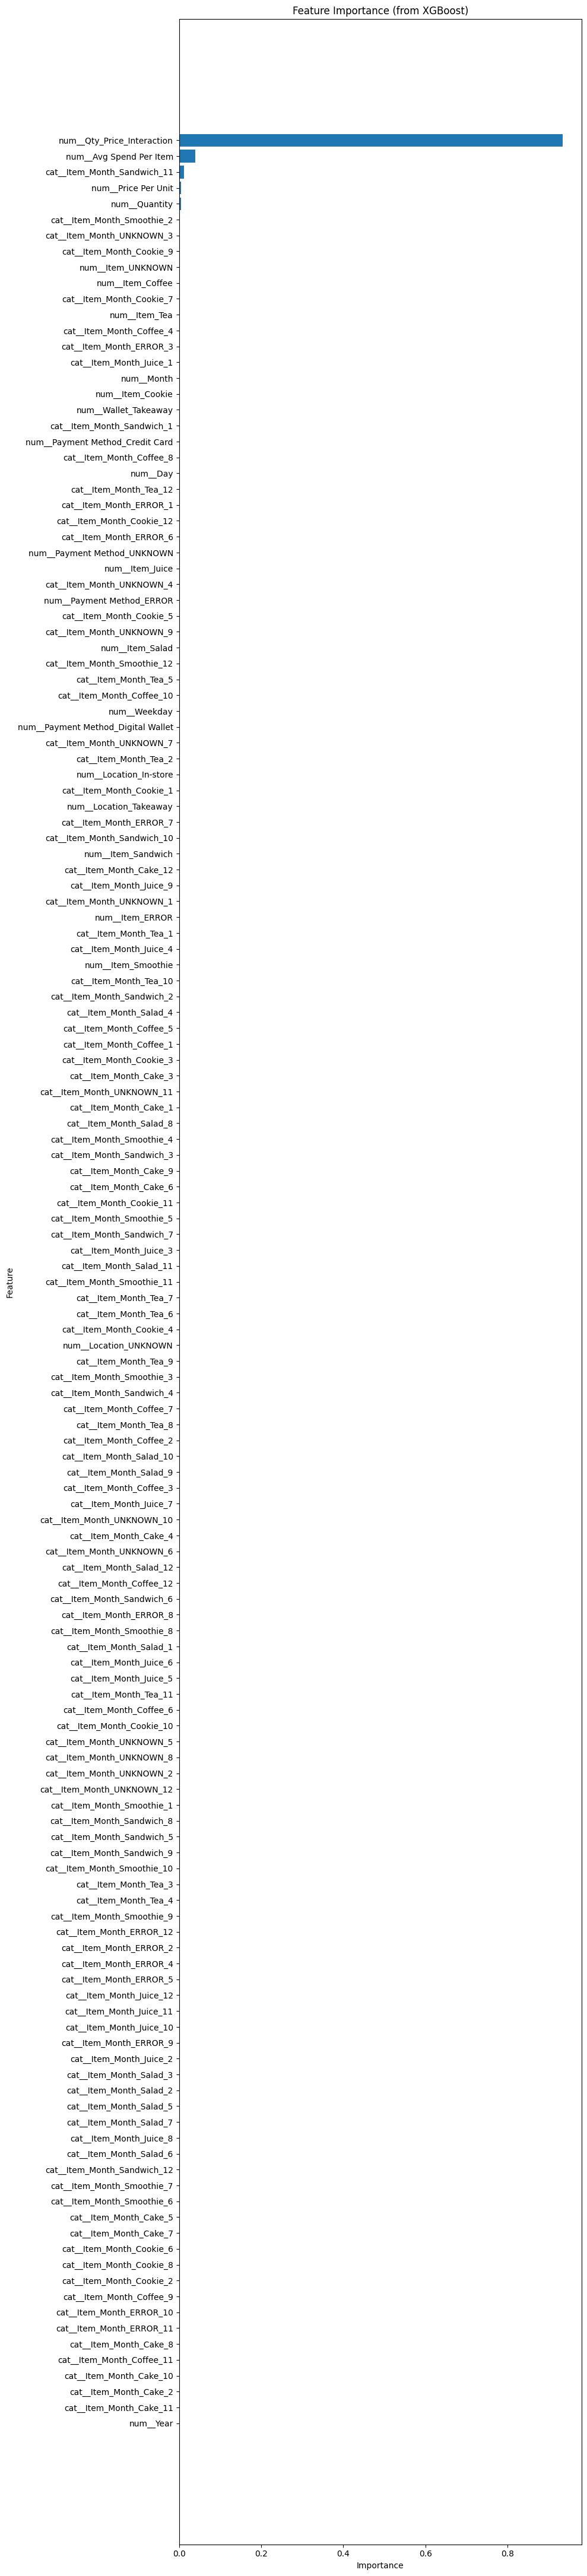

In [41]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd # Needed for select_dtypes

categorical_cols = X_train_processed.select_dtypes(include=['object']).columns
numeric_cols = X_train_processed.select_dtypes(exclude=['object']).columns

# Re-initialize the preprocessor with the correct column definitions
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Define the best model (XGBoost)
best_xgb_model = xgb.XGBRegressor(random_state=42)

# Create a pipeline that includes preprocessing and the regressor
pipeline_best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', best_xgb_model)
])

# Fit the pipeline on the processed training data
pipeline_best_model.fit(X_train_processed, y_train)

# Get feature importance from the regressor within the pipeline
importances = pipeline_best_model.named_steps['regressor'].feature_importances_

# Get the names of the features after preprocessing
processed_feature_names = pipeline_best_model.named_steps['preprocessor'].get_feature_names_out()

# Create a Series for easier sorting and plotting
feature_importance_series = pd.Series(importances, index=processed_feature_names)

# Sort features by importance for better visualization
sorted_feature_importance = feature_importance_series.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, len(sorted_feature_importance) * 0.3))
plt.barh(sorted_feature_importance.index, sorted_feature_importance.values)
plt.title("Feature Importance (from XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()